# Statistical Inference

Single notebook covering every result that appears in the Results chapter:
channel-specific regressions, the country-level DD-CDS regression, the
stacked triple-interaction regression across $\gamma$, the permutation
test, the inseparability check (appendix), and the copula tail-dependence
analysis.

In [28]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from linearmodels.panel import PanelOLS

from scipy.stats import rankdata
from scipy.optimize import minimize_scalar

In [29]:
DATE_COL    = 'date'
COUNTRY_COL = 'country'
CDS_COL     = 'cds_spread'
DD_COLS     = {'M0': 'DD_M0', 'M1': 'DD_M1', 'M2': 'DD_M2'}

EXPORTERS = ['Saudi Arabia', 'UAE (Abu Dhabi)', 'Colombia', 'Mexico',
             'Brazil', 'Egypt', 'Malaysia', 'Qatar']
CONTROLS  = ['Chile', 'China', 'Indonesia', 'Philippines',
             'South Africa', 'South Korea', 'Thailand', 'Turkey']
GROUPS    = {'Exporter': EXPORTERS, 'Control': CONTROLS}
MODELS    = ['M0', 'M1', 'M2']

GAMMA_BASELINE = 15
GAMMAS         = [5, 15, 25]
BANDWIDTHS     = [4, 8, 26]
COMPARISONS    = [('M0', 'M1', 'DD_M0', 'DD_M1'),
                  ('M0', 'M2', 'DD_M0', 'DD_M2')]

RESULTS_PATH = lambda g: f'../output/final/complete_results_weekly_{g:02d}_dampening.csv'

def stars(p):
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''

In [30]:
# Baseline panel (gamma = 0.15) - used everywhere except the gamma loop
panel = pd.read_csv(RESULTS_PATH(GAMMA_BASELINE), parse_dates=[DATE_COL])

# Macro controls - only needed for the inseparability test, but merged once here
macro = pd.read_csv('../data/macro_risk_variables.csv',
                    sep=',', dayfirst=True, parse_dates=['Date'], index_col='Date')
vix   = pd.read_csv('../data/VIXCLS.csv',
                    parse_dates=['Date'], index_col='Date')
ovx   = pd.read_csv('../data/OVXCLS.csv',
                    parse_dates=['date'], index_col='date')
gpr   = pd.read_csv('../data/geopolitical_risk_index_daily.csv',
                    sep=';', dayfirst=True, parse_dates=['date'], index_col='date',
                    decimal=',')
for col in gpr.columns:
    gpr[col] = pd.to_numeric(gpr[col], errors='coerce')

macro['VIX'] = vix['VIXCLS']
macro['OVX'] = ovx['OVXCLS']
macro = macro.join(gpr[['GPRD']], how='left')
controls_daily = macro[['VIX', 'OVX', 'DXY', 'UST10Y', 'GPRD']].copy()

cds_dates = pd.DatetimeIndex(panel[DATE_COL].unique())
controls_weekly = (controls_daily
    .reindex(cds_dates, method='nearest', tolerance=pd.Timedelta('7 days'))
    .ffill().bfill()
    .reset_index()
    .rename(columns={'index': DATE_COL, 'Date': DATE_COL}))
controls_weekly[DATE_COL] = pd.to_datetime(controls_weekly[DATE_COL])

panel = panel.drop(columns=[c for c in ['VIX', 'OVX', 'DXY', 'UST10Y', 'GPRD']
                            if c in panel.columns])
panel = pd.merge_asof(
    panel.sort_values(DATE_COL),
    controls_weekly.sort_values(DATE_COL),
    on=DATE_COL, direction='nearest', tolerance=pd.Timedelta('7 days'))
panel = panel.sort_values([COUNTRY_COL, DATE_COL]).reset_index(drop=True)

print(f'Panel shape: {panel.shape}')

Panel shape: (8352, 28)


## 1. Channel-Specific Informativeness

$$\ln(\text{CDS}_{it}) = \alpha_i + \beta_i \ln(V_{it}^{M_k}) + \varepsilon_{it},\quad k\in\{0,1\}$$

$$\ln(\text{CDS}_{it}) = \alpha_i + \beta_i \ln(\sigma_{it}^{M_k}) + \varepsilon_{it},\quad k\in\{0,2\}$$

In [31]:
channel_specs = [
    ('Regression 1: ln(CDS) = a + b ln(V)',
     [('M0', 'implied_V_M0'), ('M1', 'implied_V_M1')]),
    ('Regression 2: ln(CDS) = a + b ln(sigma)',
     [('M0', 'implied_sigma_V_M0'), ('M2', 'implied_sigma_V_M2')]),
]

for title, model_cols in channel_specs:
    print('\n' + title)
    m1, m2 = model_cols[0][0], model_cols[1][0]
    print(f"{'Country':<20} | "
          f"{m1+' alpha':>10} {'p':>7} {m1+' beta':>10} {'p':>7} {'R2':>6} {'N':>4} | "
          f"{m2+' alpha':>10} {'p':>7} {m2+' beta':>10} {'p':>7} {'R2':>6} {'N':>4}")
    print('-' * 130)

    r2 = {f'{m}_{g}': [] for m, _ in model_cols for g in ('exp', 'ctl')}

    for c in EXPORTERS + CONTROLS:
        grp = 'exp' if c in EXPORTERS else 'ctl'
        line = f'{c:<20}'
        for model, col in model_cols:
            d = panel.loc[panel[COUNTRY_COL] == c, [CDS_COL, col]].dropna()
            d = d[(d[CDS_COL] > 0) & (d[col] > 0)]
            y = np.log(d[CDS_COL])
            X = sm.add_constant(np.log(d[col]))
            res = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 8})
            a,  pa = res.params.iloc[0], res.pvalues.iloc[0]
            b,  pb = res.params.iloc[1], res.pvalues.iloc[1]
            line += (f' | {a:>9.3f}{stars(pa):<3} {pa:>7.4f}'
                     f' {b:>9.3f}{stars(pb):<3} {pb:>7.4f}'
                     f' {res.rsquared:>6.3f} {len(d):>4}')
            r2[f'{model}_{grp}'].append(res.rsquared)
        print(line)

    print('-' * 130)
    for label, g in [('Mean R2 Exporters', 'exp'), ('Mean R2 Controls', 'ctl')]:
        v1 = np.mean(r2[f'{model_cols[0][0]}_{g}'])
        v2 = np.mean(r2[f'{model_cols[1][0]}_{g}'])
        print(f'{label:<20} | {"":>43} {v1:>6.3f} {"":>4} | {"":>43} {v2:>6.3f}')


Regression 1: ln(CDS) = a + b ln(V)
Country              |   M0 alpha       p    M0 beta       p     R2    N |   M1 alpha       p    M1 beta       p     R2    N
----------------------------------------------------------------------------------------------------------------------------------
Saudi Arabia         |     7.679***  0.0000    -0.576***  0.0000  0.484  522 |     7.494***  0.0000    -0.541***  0.0000  0.536  522
UAE (Abu Dhabi)      |     7.753***  0.0000    -0.612***  0.0000  0.391  522 |     7.404***  0.0000    -0.553***  0.0000  0.445  522
Colombia             |     2.810**   0.0183     0.390*    0.0561  0.045  522 |     3.859***  0.0001     0.208     0.2060  0.021  522
Mexico               |    10.672***  0.0000    -0.848***  0.0000  0.187  522 |     9.676***  0.0000    -0.702***  0.0000  0.275  522
Brazil               |    30.387***  0.0000    -3.458***  0.0000  0.479  522 |    17.025***  0.0000    -1.609***  0.0000  0.421  522
Egypt                |    -0.590     0.682

## 2. Country-Level DD-CDS Regression

$$\ln(\text{CDS}_{it}) = \alpha_i + \beta_i\, DD_{it}^{M_k} + \varepsilon_{it},\quad k\in\{0,1,2\}$$

In [32]:
for gamma in GAMMAS:
    pg = panel if gamma == GAMMA_BASELINE else pd.read_csv(RESULTS_PATH(gamma),
                                                            parse_dates=[DATE_COL])

    print(f'\n{"#" * 180}')
    print(f'  gamma = 0.{gamma:02d}')
    print('#' * 180)

    print(f"{'Country':<20} | " +
          ' | '.join(f"{m+' alpha':>10} {'p':>7} {m+' beta':>10} {'p':>7} {'R2':>6} {'N':>4}"
                     for m in MODELS))
    print('-' * 180)

    r2    = {f'{m}_{g}': [] for m in MODELS for g in ('exp', 'ctl')}
    betas = {f'{m}_{g}': [] for m in MODELS for g in ('exp', 'ctl')}

    for c in EXPORTERS + CONTROLS:
        grp  = 'exp' if c in EXPORTERS else 'ctl'
        line = f'{c:<20}'
        for m in MODELS:
            d = pg.loc[pg[COUNTRY_COL] == c, [CDS_COL, DD_COLS[m]]].dropna()
            d = d[d[CDS_COL] > 0]
            y = np.log(d[CDS_COL].values)
            X = sm.add_constant(d[DD_COLS[m]].values)
            res = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 8})
            a, pa = res.params[0], res.pvalues[0]
            b, pb = res.params[1], res.pvalues[1]
            line += (f' | {a:>9.3f}{stars(pa):<3} {pa:>7.4f}'
                     f' {b:>9.3f}{stars(pb):<3} {pb:>7.4f}'
                     f' {res.rsquared:>6.3f} {len(d):>4}')
            r2[f'{m}_{grp}'].append(res.rsquared)
            betas[f'{m}_{grp}'].append(b)
        print(line)

    print('-' * 180)
    for label, g in [('Mean beta Exporters', 'exp'), ('Mean beta Controls', 'ctl')]:
        line = f'{label:<20}'
        for m in MODELS:
            line += f' | {"":>21} {np.mean(betas[f"{m}_{g}"]):>9.3f} {"":>22}'
        print(line)
    for label, g in [('Mean R2 Exporters', 'exp'), ('Mean R2 Controls', 'ctl')]:
        line = f'{label:<20}'
        for m in MODELS:
            line += f' | {"":>43} {np.mean(r2[f"{m}_{g}"]):>6.3f} {"":>4}'
        print(line)


####################################################################################################################################################################################
  gamma = 0.05
####################################################################################################################################################################################
Country              |   M0 alpha       p    M0 beta       p     R2    N |   M1 alpha       p    M1 beta       p     R2    N |   M2 alpha       p    M2 beta       p     R2    N
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Saudi Arabia         |     4.887***  0.0000    -0.161***  0.0000  0.411  522 |     4.869***  0.0000    -0.151***  0.0000  0.435  522 |     4.914***  0.0000    -0.175***  0.0000  0.412  522
UAE (Abu Dhabi)      |     3.953***  0.0000     0.018     0.2968  0.027  52

## 3. Stacked Triple-Interaction Regression

$$\ln(\text{CDS}_{it}) = \alpha_i + \lambda_t + \beta_1 DD_{it}
+ \beta_2 (DD\times\text{Exp}) + \beta_3 (DD\times\text{Mod})
+ \beta_4 (DD\times\text{Exp}\times\text{Mod}) + \varepsilon_{it}$$

Entity and time fixed effects, Driscoll-Kraay (Bartlett) standard errors
at three bandwidths. One loop, three $\gamma$ values, full coefficient table
for each (M0$\to$M1, M0$\to$M2).

In [34]:
stacked_results = {}  # (gamma, ext_name, bw) -> dict (used by permutation test)
stacked_results_clustered = {}  # (gamma, ext_name) -> dict for (i,t)-clustered robustness

for gamma in GAMMAS:
    pg = panel if gamma == GAMMA_BASELINE else pd.read_csv(RESULTS_PATH(gamma),
                                                            parse_dates=[DATE_COL])
    print(f'\n{"#" * 130}')
    print(f'  gamma = 0.{gamma:02d}')
    print('#' * 130)
    for _, ext_name, base_col, ext_col in COMPARISONS:
        d0 = pg[[COUNTRY_COL, DATE_COL, CDS_COL, base_col]].dropna()
        d0 = d0[d0[CDS_COL] > 0].assign(DD=lambda x: x[base_col], model=0)
        d1 = pg[[COUNTRY_COL, DATE_COL, CDS_COL, ext_col]].dropna()
        d1 = d1[d1[CDS_COL] > 0].assign(DD=lambda x: x[ext_col], model=1)
        s = pd.concat([d0[[COUNTRY_COL, DATE_COL, CDS_COL, 'DD', 'model']],
                       d1[[COUNTRY_COL, DATE_COL, CDS_COL, 'DD', 'model']]],
                      ignore_index=True)
        s['ln_cds']       = np.log(s[CDS_COL])
        s['exporter']     = s[COUNTRY_COL].isin(EXPORTERS).astype(int)
        s['exp_model']    = s['exporter'] * s['model']
        s['dd_exp']       = s['DD'] * s['exporter']
        s['dd_model']     = s['DD'] * s['model']
        s['dd_exp_model'] = s['DD'] * s['exporter'] * s['model']
        # build (country, week) cluster ID before setting the index
        s['cluster_iw']   = (s[COUNTRY_COL].astype(str) + '_' +
                             s[DATE_COL].astype(str))
        s = s.set_index([COUNTRY_COL, DATE_COL])

        regressors = ['DD', 'dd_exp', 'dd_model', 'dd_exp_model',
                      'model', 'exp_model']

        mod = PanelOLS(s['ln_cds'],
                       s[regressors],
                       entity_effects=True, time_effects=True, drop_absorbed=True)

        # ---- primary inference: Driscoll-Kraay at three bandwidths ----
        print(f'\n  M0 -> {ext_name}  (Driscoll-Kraay)')
        print(f"{'BW':>3} | {'b0 (m)':>10} {'p':>7} | {'b5 (Expxm)':>13} {'p':>7} |"
              f" {'b1 (DD)':>11} {'p':>7} | {'b2 (DDxExp)':>14} {'p':>7} |"
              f" {'b3 (DDxMod)':>14} {'p':>7} | {'b4 (DDxExpxMod)':>17} {'p':>7} |"
              f" {'b3+b4':>8} {'Wald p':>8}")
        print('  ' + '-' * 128)

        for bw in BANDWIDTHS:
            res = mod.fit(cov_type='kernel', kernel='bartlett', bandwidth=bw)
            wp  = res.wald_test(formula='dd_model + dd_exp_model = 0').pval
            b0 = res.params.get('model', np.nan)
            p0 = res.pvalues.get('model', np.nan)
            b5 = res.params.get('exp_model', np.nan)
            p5 = res.pvalues.get('exp_model', np.nan)
            stacked_results[(gamma, ext_name, bw)] = dict(
                b0=b0, p0=p0,
                b5=b5, p5=p5,
                b1=res.params['DD'],           p1=res.pvalues['DD'],
                b2=res.params['dd_exp'],       p2=res.pvalues['dd_exp'],
                b3=res.params['dd_model'],     p3=res.pvalues['dd_model'],
                b4=res.params['dd_exp_model'], p4=res.pvalues['dd_exp_model'],
                wald_p=wp)
            r = stacked_results[(gamma, ext_name, bw)]
            print(f"{bw:>3} |"
                  f" {r['b0']:>9.4f}{stars(r['p0']):<3} {r['p0']:>7.4f} |"
                  f" {r['b5']:>12.4f}{stars(r['p5']):<3} {r['p5']:>7.4f} |"
                  f" {r['b1']:>10.4f}{stars(r['p1']):<3} {r['p1']:>7.4f} |"
                  f" {r['b2']:>13.4f}{stars(r['p2']):<3} {r['p2']:>7.4f} |"
                  f" {r['b3']:>13.4f}{stars(r['p3']):<3} {r['p3']:>7.4f} |"
                  f" {r['b4']:>16.4f}{stars(r['p4']):<3} {r['p4']:>7.4f} |"
                  f" {r['b3']+r['b4']:>8.4f} {r['wald_p']:>7.4f}{stars(r['wald_p'])}")

        # ---- robustness: (i,t)-pair clustered standard errors ----
        clusters = pd.DataFrame(
            {'iw': pd.Categorical(s['cluster_iw']).codes},
            index=s.index
        )
        res_c = mod.fit(cov_type='clustered', clusters=clusters,
                        group_debias=True)
        wp_c = res_c.wald_test(formula='dd_model + dd_exp_model = 0').pval
        stacked_results_clustered[(gamma, ext_name)] = dict(
            b0=res_c.params.get('model', np.nan),
            p0=res_c.pvalues.get('model', np.nan),
            b5=res_c.params.get('exp_model', np.nan),
            p5=res_c.pvalues.get('exp_model', np.nan),
            b1=res_c.params['DD'],           p1=res_c.pvalues['DD'],
            b2=res_c.params['dd_exp'],       p2=res_c.pvalues['dd_exp'],
            b3=res_c.params['dd_model'],     p3=res_c.pvalues['dd_model'],
            b4=res_c.params['dd_exp_model'], p4=res_c.pvalues['dd_exp_model'],
            wald_p=wp_c)
        rc = stacked_results_clustered[(gamma, ext_name)]
        print(f'\n  M0 -> {ext_name}  ((country, week)-pair clustered SEs)')
        print('  ' + '-' * 128)
        print(f"     |"
              f" {rc['b0']:>9.4f}{stars(rc['p0']):<3} {rc['p0']:>7.4f} |"
              f" {rc['b5']:>12.4f}{stars(rc['p5']):<3} {rc['p5']:>7.4f} |"
              f" {rc['b1']:>10.4f}{stars(rc['p1']):<3} {rc['p1']:>7.4f} |"
              f" {rc['b2']:>13.4f}{stars(rc['p2']):<3} {rc['p2']:>7.4f} |"
              f" {rc['b3']:>13.4f}{stars(rc['p3']):<3} {rc['p3']:>7.4f} |"
              f" {rc['b4']:>16.4f}{stars(rc['p4']):<3} {rc['p4']:>7.4f} |"
              f" {rc['b3']+rc['b4']:>8.4f} {rc['wald_p']:>7.4f}{stars(rc['wald_p'])}")


##################################################################################################################################
  gamma = 0.05
##################################################################################################################################

  M0 -> M1  (Driscoll-Kraay)
 BW |     b0 (m)       p |    b5 (Expxm)       p |     b1 (DD)       p |    b2 (DDxExp)       p |    b3 (DDxMod)       p |   b4 (DDxExpxMod)       p |    b3+b4   Wald p
  --------------------------------------------------------------------------------------------------------------------------------
  4 |    0.0048***  0.0004 |       0.0561***  0.0000 |    -0.0299***  0.0000 |       -0.0352***  0.0001 |       -0.0007***  0.0045 |          -0.0171***  0.0001 |  -0.0178  0.0000***
  8 |    0.0048***  0.0050 |       0.0561***  0.0016 |    -0.0299***  0.0003 |       -0.0352***  0.0018 |       -0.0007**   0.0244 |          -0.0171***  0.0027 |  -0.0178  0.0014***
 26 |    0.0048**   0.0455

## 4. Permutation Test

Randomly reassign the model label (M0 vs extension) at the row level
across 500 draws; record $\beta_4$ each time. Empirical $p$ is the fraction
of placebo $\beta_4$ at least as negative as the observed value.

In [20]:
N_PERM = 2000

print(f'Permutation test — gamma = 0.{GAMMA_BASELINE:02d}, {N_PERM} draws per swap type')
print('Perm 1: exporter/control labels swapped at country level')
print('Perm 2: baseline/extension labels swapped at country-week level')

for _, ext_name, base_col, ext_col in COMPARISONS:
    # ---- Build aligned country-week frame once ----
    d0 = panel[[COUNTRY_COL, DATE_COL, CDS_COL, base_col]].dropna()
    d0 = d0[d0[CDS_COL] > 0]
    d1 = panel[[COUNTRY_COL, DATE_COL, ext_col]].dropna()
    m  = pd.merge(d0, d1, on=[COUNTRY_COL, DATE_COL]).sort_values([COUNTRY_COL, DATE_COL])
    n  = len(m)

    country_arr = m[COUNTRY_COL].values
    date_arr    = m[DATE_COL].values
    ln_cds_arr  = np.log(m[CDS_COL].values)
    base_vals   = m[base_col].values
    ext_vals    = m[ext_col].values
    exp_true    = m[COUNTRY_COL].isin(EXPORTERS).astype(int).values

    # Stacked structure: M0 first half, extension second half
    country_st = np.concatenate([country_arr, country_arr])
    date_st    = np.concatenate([date_arr,    date_arr])
    ln_cds_st  = np.concatenate([ln_cds_arr,  ln_cds_arr])
    model_st   = np.concatenate([np.zeros(n), np.ones(n)])
    DD_true    = np.concatenate([base_vals,   ext_vals])
    exp_st_true = np.concatenate([exp_true,   exp_true])

    idx = pd.MultiIndex.from_arrays([country_st, date_st], names=[COUNTRY_COL, DATE_COL])
    y   = pd.Series(ln_cds_st, index=idx)

    def fit(DD_st, exp_st):
        X = pd.DataFrame({
            'DD':           DD_st,
            'dd_exp':       DD_st * exp_st,
            'dd_model':     DD_st * model_st,
            'dd_exp_model': DD_st * exp_st * model_st,
        }, index=idx)
        res = PanelOLS(y, X, entity_effects=True, time_effects=True,
                       drop_absorbed=True).fit()
        return res.params['dd_model'], res.params['dd_exp_model']

    # Observed coefficients (from gamma=15, BW=4 fit already in stacked_results)
    obs_b3  = stacked_results[(GAMMA_BASELINE, ext_name, 4)]['b3']
    obs_b4  = stacked_results[(GAMMA_BASELINE, ext_name, 4)]['b4']
    obs_sum = obs_b3 + obs_b4

    # ---- Perm 1: exporter/control swap (country level) ----
    countries_all = np.array(EXPORTERS + CONTROLS)
    n_exp = len(EXPORTERS)
    p1_b3 = np.empty(N_PERM); p1_b4 = np.empty(N_PERM)
    np.random.seed(42)
    for i in range(N_PERM):
        fake = np.random.choice(countries_all, size=n_exp, replace=False)
        exp_perm = np.isin(country_arr, fake).astype(int)
        exp_st   = np.concatenate([exp_perm, exp_perm])
        p1_b3[i], p1_b4[i] = fit(DD_true, exp_st)
        if (i + 1) % 500 == 0:
            print(f'  [{ext_name}] exp swap  {i+1:>4}/{N_PERM}')
    p1_sum = p1_b3 + p1_b4

    # ---- Perm 2: baseline/extension swap (country-week level) ----
    p2_b3 = np.empty(N_PERM); p2_b4 = np.empty(N_PERM)
    np.random.seed(42)
    for i in range(N_PERM):
        swap  = np.random.binomial(1, 0.5, size=n).astype(bool)
        dd0   = np.where(swap, ext_vals, base_vals)
        dd1   = np.where(swap, base_vals, ext_vals)
        DD_st = np.concatenate([dd0, dd1])
        p2_b3[i], p2_b4[i] = fit(DD_st, exp_st_true)
        if (i + 1) % 500 == 0:
            print(f'  [{ext_name}] mod swap  {i+1:>4}/{N_PERM}')
    p2_sum = p2_b3 + p2_b4

    # One-sided empirical p in the direction of the observed value
    def pp(placebo, obs):
        return np.mean(placebo <= obs) if obs < 0 else np.mean(placebo >= obs)

    print(f'\nM0 -> {ext_name}')
    print(f"  {'Stat':<7} | {'Observed':>9} | "
          f"{'Exp swap mean':>14} {'std':>7} {'p':>7} | "
          f"{'Mod swap mean':>14} {'std':>7} {'p':>7}")
    print('  ' + '-' * 90)
    for name, obs, pl1, pl2 in [('b3',    obs_b3,  p1_b3,  p2_b3),
                                ('b3+b4', obs_sum, p1_sum, p2_sum),
                                ('b4',    obs_b4,  p1_b4,  p2_b4)]:
        print(f"  {name:<7} | {obs:>9.4f} | "
              f"{pl1.mean():>14.4f} {pl1.std():>7.4f} {pp(pl1, obs):>7.4f} | "
              f"{pl2.mean():>14.4f} {pl2.std():>7.4f} {pp(pl2, obs):>7.4f}")

Permutation test — gamma = 0.15, 2000 draws per swap type
Perm 1: exporter/control labels swapped at country level
Perm 2: baseline/extension labels swapped at country-week level


KeyboardInterrupt: 

## 5. Signal Decomposition (Appendix)

OVX and convenience yield projected on standard global risk factors
(VIX, DXY, UST10Y, GPRD).

In [9]:
ts = (panel.drop_duplicates(subset=[DATE_COL])
          .set_index(DATE_COL)
          [['OVX', 'convenience_yield', 'VIX', 'DXY', 'UST10Y', 'GPRD']]
          .sort_index())

for dep in ['OVX', 'convenience_yield']:
    sub = ts[[dep, 'VIX', 'DXY', 'UST10Y', 'GPRD']].dropna()
    res = sm.OLS(sub[dep], sm.add_constant(sub[['VIX', 'DXY', 'UST10Y', 'GPRD']])).fit()

    print(f'\n{dep} ~ Global Factors')
    print(f'  R2: {res.rsquared:.4f}   Adj. R2: {res.rsquared_adj:.4f}')
    print(f"  {'Variable':<10} {'Beta':>10} {'p-value':>10}")
    print('  ' + '-' * 32)
    for v in res.params.index:
        print(f'  {v:<10} {res.params[v]:>10.4f} {res.pvalues[v]:>10.4f}')


OVX ~ Global Factors
  R2: 0.5903   Adj. R2: 0.5872
  Variable         Beta    p-value
  --------------------------------
  const       -101.0461     0.0000
  VIX            1.4614     0.0000
  DXY            1.3520     0.0000
  UST10Y        -7.6438     0.0000
  GPRD           0.0104     0.3573

convenience_yield ~ Global Factors
  R2: 0.2687   Adj. R2: 0.2630
  Variable         Beta    p-value
  --------------------------------
  const          0.1795     0.0742
  VIX           -0.0004     0.4985
  DXY           -0.0030     0.0100
  UST10Y         0.0530     0.0000
  GPRD           0.0002     0.0142


## 6. Copula Analysis of Tail Dependence

Within-country pseudo-uniform pairs $(u, v) = (\text{rank}(\text{CDS}),
\text{rank}(-\text{DD}))$ pooled across countries. One bootstrap loop
produces Gumbel $\theta$ + $\lambda_U = 2 - 2^{1/\theta}$ (Table 5),
$\bar{R}$ over $z\in[0.01,0.10]$ (Table 6), and $R(z)$ bands for the figure.

In [14]:
def gumbel_loglik(u, v, theta):
    if theta < 1 + 1e-6: return -np.inf
    lu = -np.log(np.clip(u, 1e-10, 1 - 1e-10))
    lv = -np.log(np.clip(v, 1e-10, 1 - 1e-10))
    A  = lu**theta + lv**theta
    return np.sum(-A**(1/theta) + (1/theta - 2) * np.log(A)
                  + (theta - 1) * (np.log(lu) + np.log(lv))
                  - np.log(u) - np.log(v) + np.log(A**(-1/theta) + theta - 1))

fit_gumbel = lambda u, v: minimize_scalar(lambda th: -gumbel_loglik(u, v, th),
                                          bounds=(1.001, 20), method='bounded').x

def pseudo_unif(arrays):
    u, v = [], []
    for a in arrays:
        n = len(a)
        u.append(rankdata(a[:, 0])  / (n + 1))
        v.append(rankdata(-a[:, 1]) / (n + 1))
    return np.concatenate(u), np.concatenate(v)

def R_curve(u, v, z):
    return np.array([np.mean((u >= 1 - zi) & (v >= 1 - zi)) / np.mean(u >= 1 - zi)
                     for zi in z])

N_BOOT         = 500
Z_FIG          = np.logspace(-2, np.log10(0.45), 80)
Z_RBAR         = np.linspace(0.01, 0.05, 100)
copula_results = {}

for group_name, countries in GROUPS.items():
    for model in MODELS:
        arrs = [panel.loc[panel[COUNTRY_COL] == c, [CDS_COL, DD_COLS[model]]]
                     .dropna().values for c in countries]
        arrs = [a for a in arrs if len(a) >= 10]

        u_pt, v_pt = pseudo_unif(arrs)
        theta_pt   = fit_gumbel(u_pt, v_pt)

        np.random.seed(42)
        boot_theta = np.empty(N_BOOT)
        boot_Rbar  = np.empty(N_BOOT)
        boot_Rfig  = np.empty((N_BOOT, len(Z_FIG)))
        for i in range(N_BOOT):
            resamp = [a[np.random.choice(len(a), len(a), replace=True)] for a in arrs]
            u_b, v_b      = pseudo_unif(resamp)
            boot_theta[i] = fit_gumbel(u_b, v_b)
            boot_Rbar[i]  = R_curve(u_b, v_b, Z_RBAR).mean()
            boot_Rfig[i]  = R_curve(u_b, v_b, Z_FIG)

        boot_lam = 2 - 2 ** (1 / boot_theta)

        copula_results[(group_name, model)] = dict(
            theta      = theta_pt,
            lam        = 2 - 2 ** (1 / theta_pt),
            R_bar      = R_curve(u_pt, v_pt, Z_RBAR).mean(),
            R_fig_pt   = R_curve(u_pt, v_pt, Z_FIG),
            lam_ci     = (np.percentile(boot_lam,  2.5), np.percentile(boot_lam,  97.5)),
            R_bar_ci   = (np.percentile(boot_Rbar, 2.5), np.percentile(boot_Rbar, 97.5)),
            R_fig_low  = np.percentile(boot_Rfig,  2.5,  axis=0),
            R_fig_high = np.percentile(boot_Rfig,  97.5, axis=0),
        )

print(f'Done — {len(copula_results)} group-model combinations.')

Done — 6 group-model combinations.


In [15]:
# Tables 5 and 6
print('Table 5 — Gumbel')
print(f"{'Group':<10} {'Model':<6} {'theta':>7} {'lambda':>8} {'CI low':>9} {'CI high':>9}")
print('-' * 55)
for group_name in GROUPS:
    for model in MODELS:
        r = copula_results[(group_name, model)]
        print(f'{group_name:<10} {model:<6} {r["theta"]:>7.3f} {r["lam"]:>8.3f} '
              f'{r["lam_ci"][0]:>9.3f} {r["lam_ci"][1]:>9.3f}')
    print()

print('Table 6 — R_bar over z in [0.01, 0.05]')
print(f"{'Group':<10} {'Model':<6} {'R_bar':>7} {'CI low':>9} {'CI high':>9}")
print('-' * 45)
for group_name in GROUPS:
    for model in MODELS:
        r = copula_results[(group_name, model)]
        print(f'{group_name:<10} {model:<6} {r["R_bar"]:>7.3f} '
              f'{r["R_bar_ci"][0]:>9.3f} {r["R_bar_ci"][1]:>9.3f}')
    print()

Table 5 — Gumbel
Group      Model    theta   lambda    CI low   CI high
-------------------------------------------------------
Exporter   M0       1.724    0.505     0.498     0.513
Exporter   M1       1.942    0.571     0.562     0.580
Exporter   M2       1.796    0.529     0.521     0.537

Control    M0       1.519    0.422     0.414     0.430
Control    M1       1.621    0.466     0.458     0.475
Control    M2       1.589    0.453     0.444     0.461

Table 6 — R_bar over z in [0.01, 0.05]
Group      Model    R_bar    CI low   CI high
---------------------------------------------
Exporter   M0       0.117     0.083     0.161
Exporter   M1       0.335     0.281     0.380
Exporter   M2       0.240     0.191     0.282

Control    M0       0.058     0.027     0.082
Control    M1       0.148     0.114     0.182
Control    M2       0.062     0.035     0.085



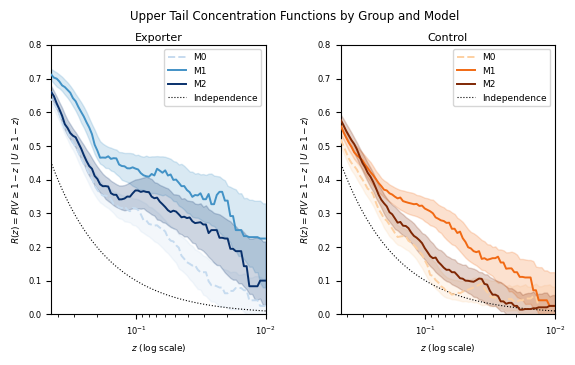

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(6.5, 3.5))
plt.subplots_adjust(wspace=0.35)

colors = {'Exporter': {'M0': '#c6dbef', 'M1': '#4292c6', 'M2': '#08306b'},
          'Control':  {'M0': '#fdd0a2', 'M1': '#f16913', 'M2': '#7f2704'}}
styles = {'M0': '--', 'M1': '-', 'M2': '-'}

for ax, group_name in zip(axes, GROUPS):
    for model in MODELS:
        r = copula_results[(group_name, model)]
        c = colors[group_name][model]
        ax.plot(Z_FIG, r['R_fig_pt'], color=c, linestyle=styles[model],
                linewidth=1.4, label=model, zorder=3)
        ax.fill_between(Z_FIG, r['R_fig_low'], r['R_fig_high'],
                        color=c, alpha=0.2, zorder=2)
    ax.plot(Z_FIG, Z_FIG, 'k:', linewidth=0.8, label='Independence')
    ax.set_xscale('log')
    ax.set_title(group_name, fontsize=8, pad=3)
    ax.set_xlabel(r'$z$ (log scale)', fontsize=6.5)
    ax.set_ylabel(r'$R(z) = P(V \geq 1-z \mid U \geq 1-z)$', fontsize=6.5)
    ax.legend(fontsize=6.5, framealpha=0.8)
    ax.set_xlim(0.45, Z_FIG[0])
    ax.set_ylim(0, 0.8)
    ax.tick_params(labelsize=6)

fig.suptitle('Upper Tail Concentration Functions by Group and Model',
             fontsize=8.5, fontweight='normal')
plt.show()